In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a professional business style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.autolayout': True})

print("--- Phase 1: Elite Data Exploration & Business Discovery ---")
print("Loading the raw dataset...")

# Load the data
df = pd.read_csv('../data/raw/fraudTrain.csv')

# --- ELITE ADDITION: Fraud Removal Explanation ---
print("\n[Data Cleansing]: Removing fraudulent transactions.")
print("Reason: Fraudulent spikes distort true organic customer behavior. To accurately predict Customer Lifetime Value (CLV), we must isolate authentic spending habits.")
df = df[df['is_fraud'] == 0]

# Convert dates
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# --- ELITE ADDITION: Dataset Structure & Columns ---
print(f"\nDataset shape after cleaning: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("\nColumns available for analysis:")
print(df.columns.tolist())

# Summary Statistics
print(f"\nTotal Unique Customers: {df['cc_num'].nunique():,}")
print(f"Average transactions per customer: {len(df)/df['cc_num'].nunique():.2f}")
print(f"Date Range: {df['trans_date_trans_time'].min().date()} to {df['trans_date_trans_time'].max().date()}")

print("\n--- Data Preview ---")
display(df[['trans_date_trans_time', 'cc_num', 'amt', 'category', 'age']].head())

--- Phase 1: Elite Data Exploration & Business Discovery ---
Loading the raw dataset...

[Data Cleansing]: Removing fraudulent transactions.
Reason: Fraudulent spikes distort true organic customer behavior. To accurately predict Customer Lifetime Value (CLV), we must isolate authentic spending habits.

Dataset shape after cleaning: 1,289,169 rows, 24 columns

Columns available for analysis:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'age']

Total Unique Customers: 908
Average transactions per customer: 1419.79
Date Range: 2019-01-01 to 2020-06-21

--- Data Preview ---


,trans_date_trans_time,cc_num,amt,category,age
0,2019-01-01 00:00:18,2703186189652095,4.97,misc_net,30
1,2019-01-01 00:00:44,630423337322,107.23,grocery_pos,40
2,2019-01-01 00:00:51,38859492057661,220.11,entertainment,56
3,2019-01-01 00:01:16,3534093764340240,45.00,gas_transport,52
4,2019-01-01 00:03:06,375534208663984,41.96,misc_pos,32



Generating Demographics...


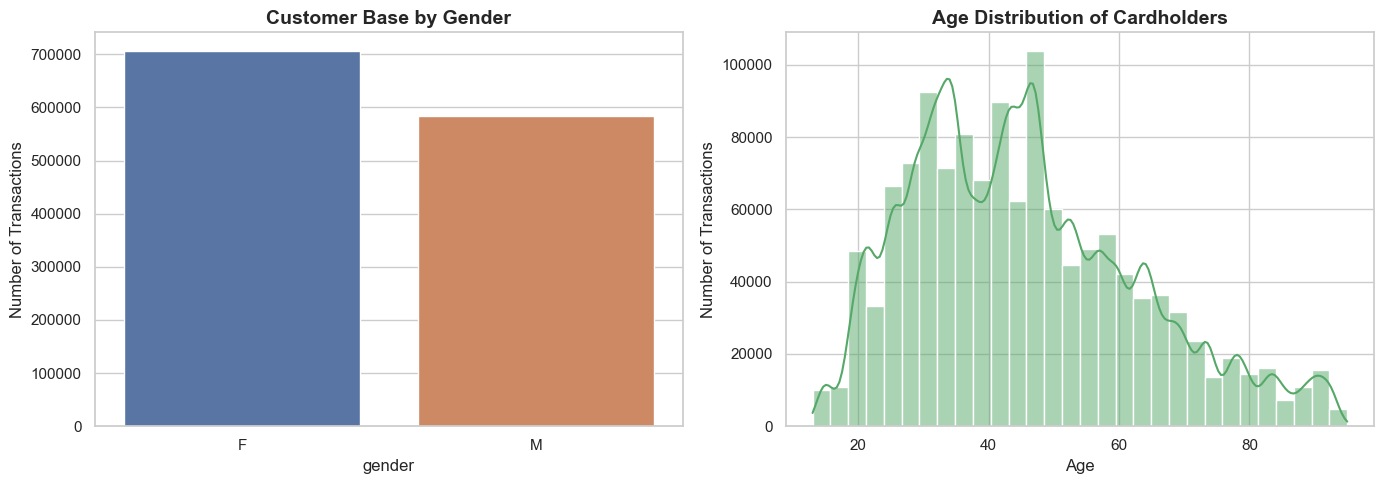

In [3]:
# ---------------------------------------------------------
# Slide 1: Customer Demographics
# ---------------------------------------------------------
print("\nGenerating Demographics...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='gender', hue='gender', palette=['#4C72B0', '#DD8452'], ax=axes[0], legend=False)
axes[0].set_title('Customer Base by Gender', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')

sns.histplot(df['age'], bins=30, kde=True, color='#55A868', ax=axes[1])
axes[1].set_title('Age Distribution of Cardholders', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
# FINAL POLISH 1: Correct Y-Axis Label
axes[1].set_ylabel('Number of Transactions')

plt.savefig('../data/presentation_demographics.png', dpi=300)
plt.show()

Generating Category & Frequency Analysis...


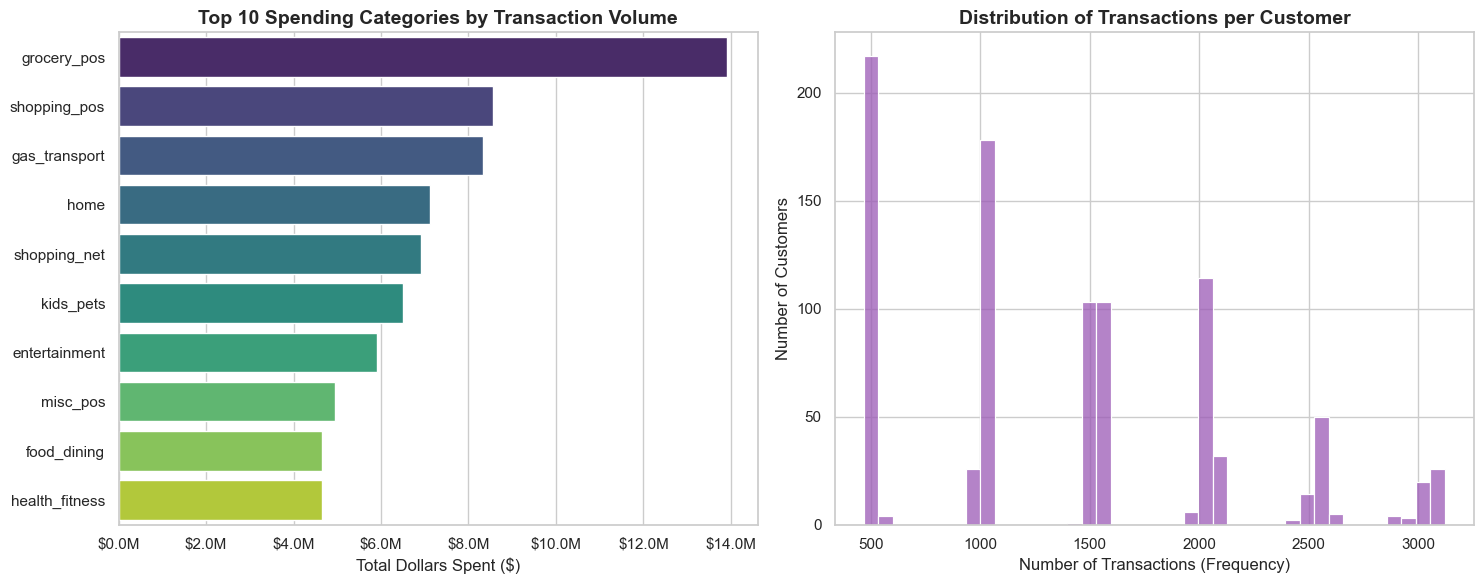

In [12]:
# ---------------------------------------------------------
# Slide 2: Category & Frequency Analysis
# ---------------------------------------------------------
print("Generating Category & Frequency Analysis...")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

category_spend = df.groupby('category')['amt'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=category_spend.values, y=category_spend.index, hue=category_spend.index, palette="viridis", ax=axes[0], legend=False)
# FINAL POLISH 2: Professional Title
axes[0].set_title('Top 10 Spending Categories by Transaction Volume', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Dollars Spent ($)', fontsize=12)
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:.1f}M".format(x/1e6)))

txn_per_user = df.groupby('cc_num').size()
sns.histplot(txn_per_user, bins=40, color='#9b59b6', ax=axes[1])
axes[1].set_title('Distribution of Transactions per Customer', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Transactions (Frequency)')
axes[1].set_ylabel('Number of Customers')

plt.savefig('../data/presentation_categories_frequency.png', dpi=300)
plt.show()

Generating Macro Timeline...


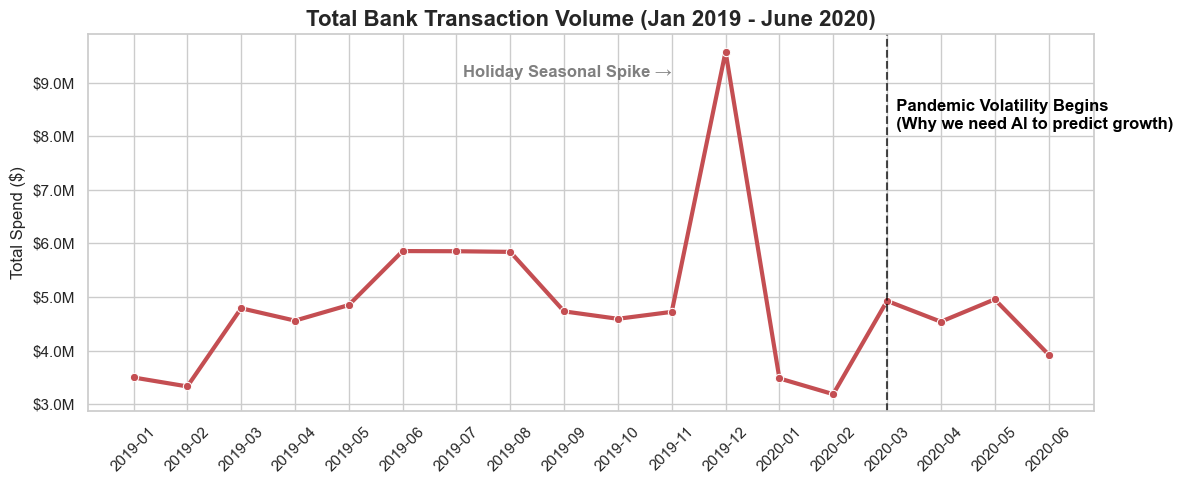

In [27]:
# ---------------------------------------------------------
# Slide 3: The Macro Timeline (The Hook)
# ---------------------------------------------------------
print("Generating Macro Timeline...")

df['year_month'] = df['trans_date_trans_time'].dt.to_period('M')
monthly_spend = df.groupby('year_month')['amt'].sum().reset_index()
monthly_spend['year_month'] = monthly_spend['year_month'].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_spend, x='year_month', y='amt', marker='o', linewidth=3, color='#C44E52')

plt.title('Total Bank Transaction Volume (Jan 2019 - June 2020)', fontsize=16, fontweight='bold')
plt.ylabel('Total Spend ($)', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=45)

plt.axvline(x='2020-03', color='black', linestyle='--', alpha=0.7)
plt.text('2020-03', monthly_spend['amt'].max() * 0.85, '  Pandemic Volatility Begins\n  (Why we need AI to predict growth)', color='black', fontweight='bold')

# FINAL POLISH 3: Explain the December Spike
plt.text('2019-11', monthly_spend['amt'].max() * 0.95, 'Holiday Seasonal Spike →', color='gray', fontweight='bold', ha='right')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:.1f}M".format(x/1e6)))

plt.savefig('../data/presentation_timeline.png', dpi=300)
plt.show()

Generating Precision Pareto Analysis...


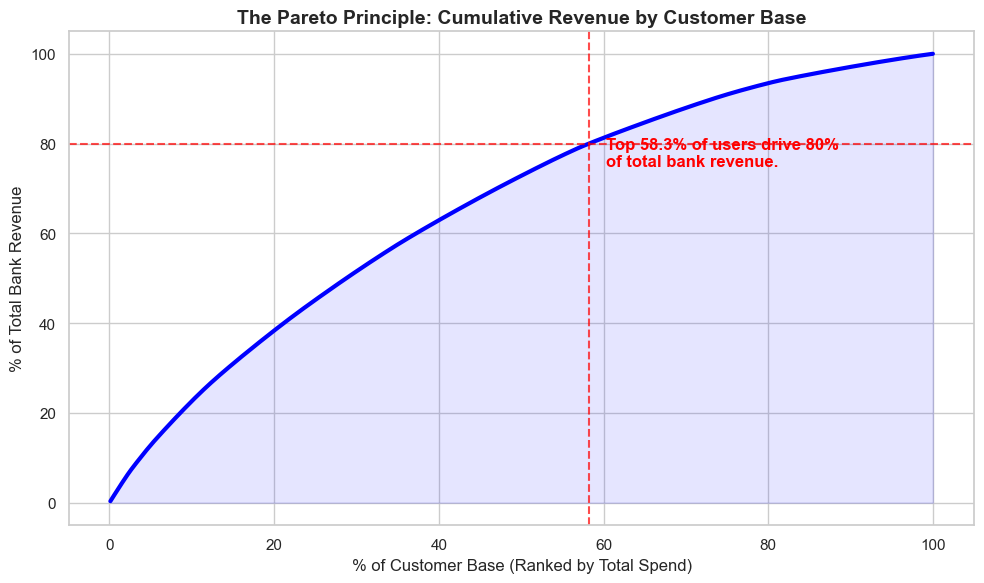

In [28]:
print("Generating Precision Pareto Analysis...")

user_spend = df.groupby('cc_num')['amt'].sum().sort_values(ascending=False)
user_spend_cumulative = user_spend.cumsum() / user_spend.sum() * 100
customer_percentiles = np.arange(1, len(user_spend) + 1) / len(user_spend) * 100

plt.figure(figsize=(10, 6))
plt.plot(customer_percentiles, user_spend_cumulative.values, color='blue', linewidth=3)
plt.fill_between(customer_percentiles, user_spend_cumulative.values, color='blue', alpha=0.1)

# Elite Fix 4: Exact 80% Math
idx_80 = np.argmax(user_spend_cumulative.values >= 80)
exact_percentile = customer_percentiles[idx_80]

plt.axhline(y=80, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=exact_percentile, color='red', linestyle='--', alpha=0.7)

plt.title('The Pareto Principle: Cumulative Revenue by Customer Base', fontsize=14, fontweight='bold')
plt.xlabel('% of Customer Base (Ranked by Total Spend)', fontsize=12)
plt.ylabel('% of Total Bank Revenue', fontsize=12)

plt.text(exact_percentile + 2, 75, f'Top {exact_percentile:.1f}% of users drive 80%\nof total bank revenue.', color='red', fontweight='bold')

plt.savefig('../data/presentation_pareto.png', dpi=300)
plt.show()

Generating Behavioral Correlation Heatmap...


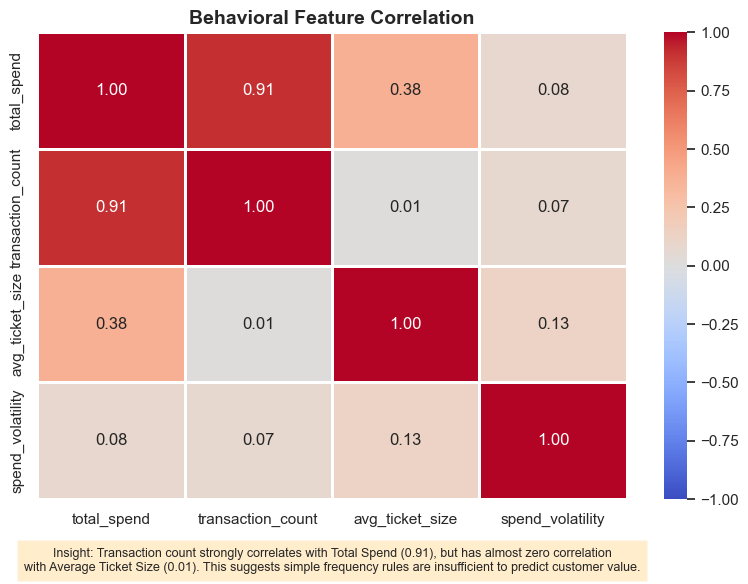


✅ Elite Business Presentation charts have been successfully generated!


In [29]:
# ---------------------------------------------------------
# Slide 5: Behavioral Correlation Heatmap
# ---------------------------------------------------------
print("Generating Behavioral Correlation Heatmap...")

behavior_df = df.groupby('cc_num').agg(
    total_spend=('amt', 'sum'),
    transaction_count=('amt', 'count'),
    avg_ticket_size=('amt', 'mean'),
    spend_volatility=('amt', 'std') 
).fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(behavior_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f', linewidths=1)

plt.title('Behavioral Feature Correlation', fontsize=14, fontweight='bold')

# FINAL POLISH 5: Fixed math and formatting on the insight box
insight_text = "Insight: Transaction count strongly correlates with Total Spend (0.91), but has almost zero correlation\nwith Average Ticket Size (0.01). This suggests simple frequency rules are insufficient to predict customer value."
plt.xlabel(insight_text, fontsize=9, bbox={"facecolor":"orange", "alpha":0.2, "pad":5}, labelpad=15)

plt.savefig('../data/presentation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Elite Business Presentation charts have been successfully generated!")